In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ML-D1-LinearRegression.xlsx to ML-D1-LinearRegression.xlsx


In [ ]:
#Read exel file
df = pd.read_excel('ML-D1-LinearRegression.xlsx')
# Display first  rows
df.head()

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
0,19.0,female,NaN,0,yes,southwest,16884.92400
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520


In [ ]:

df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'gender', 'BMI', 'Children', 'smoking_status', 'location',
       'health_insurance_price'],
      dtype='object')

In [ ]:
df.dtypes

,0
age,float64
gender,object
BMI,float64
Children,int64
smoking_status,object
location,object
health_insurance_price,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     1310 non-null   float64
 1   gender                  1338 non-null   object 
 2   BMI                     1315 non-null   float64
 3   Children                1338 non-null   int64  
 4   smoking_status          1338 non-null   object 
 5   location                1338 non-null   object 
 6   health_insurance_price  1336 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 73.3+ KB


In [ ]:
df.duplicated().any()

np.True_

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()]

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
581,19.0,male,30.59,0,no,northwest,1639.5631


In [ ]:
data1 = df.drop_duplicates()

In [ ]:
data1.shape

(1337, 7)

In [ ]:
#check missing values
data1.isnull().any()

,0
age,True
gender,False
BMI,True
Children,False
smoking_status,False
location,False
health_insurance_price,True


In [ ]:
data1.isnull().sum()

,0
age,28
gender,0
BMI,23
Children,0
smoking_status,0
location,0
health_insurance_price,2


In [ ]:
#Indexing columns
df = data1.isnull().sum().reset_index()
#Rename column
df.columns = ['column', 'null_records']
#Create new colums and gind out null value percentage
df['% null_records'] = (df['null_records']/1337)*100
df

,column,null_records,% null_records
0,age,28,2.094241
1,gender,0,0.000000
2,BMI,23,1.720269
3,Children,0,0.000000
4,smoking_status,0,0.000000
5,location,0,0.000000
6,health_insurance_price,2,0.149589


In [ ]:
data1 = data1.dropna()

In [ ]:
data1.shape

(1284, 7)

In [ ]:

data1.head()

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520
5,31.0,female,25.740,0,no,southeast,3756.62160


In [ ]:
data1.tail()

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
1333,50.0,male,30.97,3,no,northwest,10600.5483
1334,18.0,female,31.92,0,no,northeast,2205.9808
1335,18.0,female,36.85,0,no,southeast,1629.8335
1336,21.0,female,25.80,0,no,southwest,2007.9450
1337,61.0,female,29.07,0,yes,northwest,29141.3603


In [ ]:
# List of Categorical and Numeric Columns

Numerical_columns = data1.select_dtypes(include="number").columns.to_list()
print(Numerical_columns)

['age', 'BMI', 'Children', 'health_insurance_price']


In [ ]:

Categorical_columns = data1.select_dtypes(exclude="number").columns.to_list()
print(Categorical_columns)

['gender', 'smoking_status', 'location']


In [ ]:

# Statistical Measure of Numeric Columns
data1.describe()

,age,BMI,Children,health_insurance_price
count,1284.000000,1284.000000,1284.000000,1284.000000
mean,39.174455,30.618302,1.087227,13185.606206
std,14.095016,6.105360,1.206707,12061.626761
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.180000,0.000000,4719.683425
50%,39.000000,30.300000,1.000000,9333.014350
75%,51.000000,34.520000,2.000000,16452.097988
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Categorical column extraction
data1.describe(include="object")

,gender,smoking_status,location
count,1284,1284,1284
unique,2,2,4
top,male,no,southeast
freq,651,1022,351


In [ ]:
# Check the value count of categories
data1['gender'].value_counts()

,count
gender,
male,651
female,633


In [ ]:
# Check the value count of categories
data1['smoking_status'].value_counts()

,count
smoking_status,
no,1022
yes,262


In [ ]:
# Check the value count of categories
data1['location'].value_counts()

,count
location,
southeast,351
northeast,316
northwest,309
southwest,308


In [ ]:
for col in Categorical_columns:
    print(data1[col].value_counts())
    print("")
    print(".....")

gender
male      651
female    633
Name: count, dtype: int64

.....
smoking_status
no     1022
yes     262
Name: count, dtype: int64

.....
location
southeast    351
northeast    316
northwest    309
southwest    308
Name: count, dtype: int64

.....


In [ ]:
data1

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
1,18.0,male,33.770,1,no,southeast,1725.55230
2,28.0,male,33.000,3,no,southeast,4449.46200
3,33.0,male,22.705,0,no,northwest,21984.47061
4,32.0,male,28.880,0,no,northwest,3866.85520
5,31.0,female,25.740,0,no,southeast,3756.62160
...,...,...,...,...,...,...,...
1333,50.0,male,30.970,3,no,northwest,10600.54830
1334,18.0,female,31.920,0,no,northeast,2205.98080
1335,18.0,female,36.850,0,no,southeast,1629.83350
1336,21.0,female,25.800,0,no,southwest,2007.94500


In [ ]:
# 1. what is average cost of insurance from southwest region for male and female
sw_df = data1[data1['location'] == 'southwest']
sw_df.groupby('gender')['health_insurance_price'].mean().reset_index()

,gender,health_insurance_price
0,female,11181.111599
1,male,13590.071110


In [ ]:
# 2. What is average insurance cost for smokers and non-smokers

data1.groupby('smoking_status')['health_insurance_price'].mean().reset_index()

,smoking_status,health_insurance_price
0,no,8363.178479
1,yes,31996.755585


In [ ]:
# 3. Which region is having highest insurance cost for male and female

data1.groupby(['gender', 'location'])['health_insurance_price'].mean().reset_index().sort_values(
    by='health_insurance_price',
    ascending=False
)

,gender,location,health_insurance_price
6,male,southeast,15679.856023
4,male,northeast,13809.306164
7,male,southwest,13590.071110
2,female,southeast,13106.712310
0,female,northeast,13002.117965
5,male,northwest,12346.484142
1,female,northwest,12296.505537
3,female,southwest,11181.111599


In [ ]:
# 4. Which region is having lowest insurance cost for male and female

data1.groupby(['gender', 'location'])['health_insurance_price'].mean().reset_index().sort_values(
    by='health_insurance_price',
    ascending=True
)

,gender,location,health_insurance_price
3,female,southwest,11181.111599
1,female,northwest,12296.505537
5,male,northwest,12346.484142
0,female,northeast,13002.117965
2,female,southeast,13106.712310
7,male,southwest,13590.071110
4,male,northeast,13809.306164
6,male,southeast,15679.856023


In [ ]:
# 5. average insurance cost for female with age greater than 35.

female_age = data1[
    (data1['gender'] == 'female') & (data1['age'] > 35)
]

female_age['health_insurance_price'].mean()

np.float64(15069.436895482093)

In [ ]:
# Data Visualization

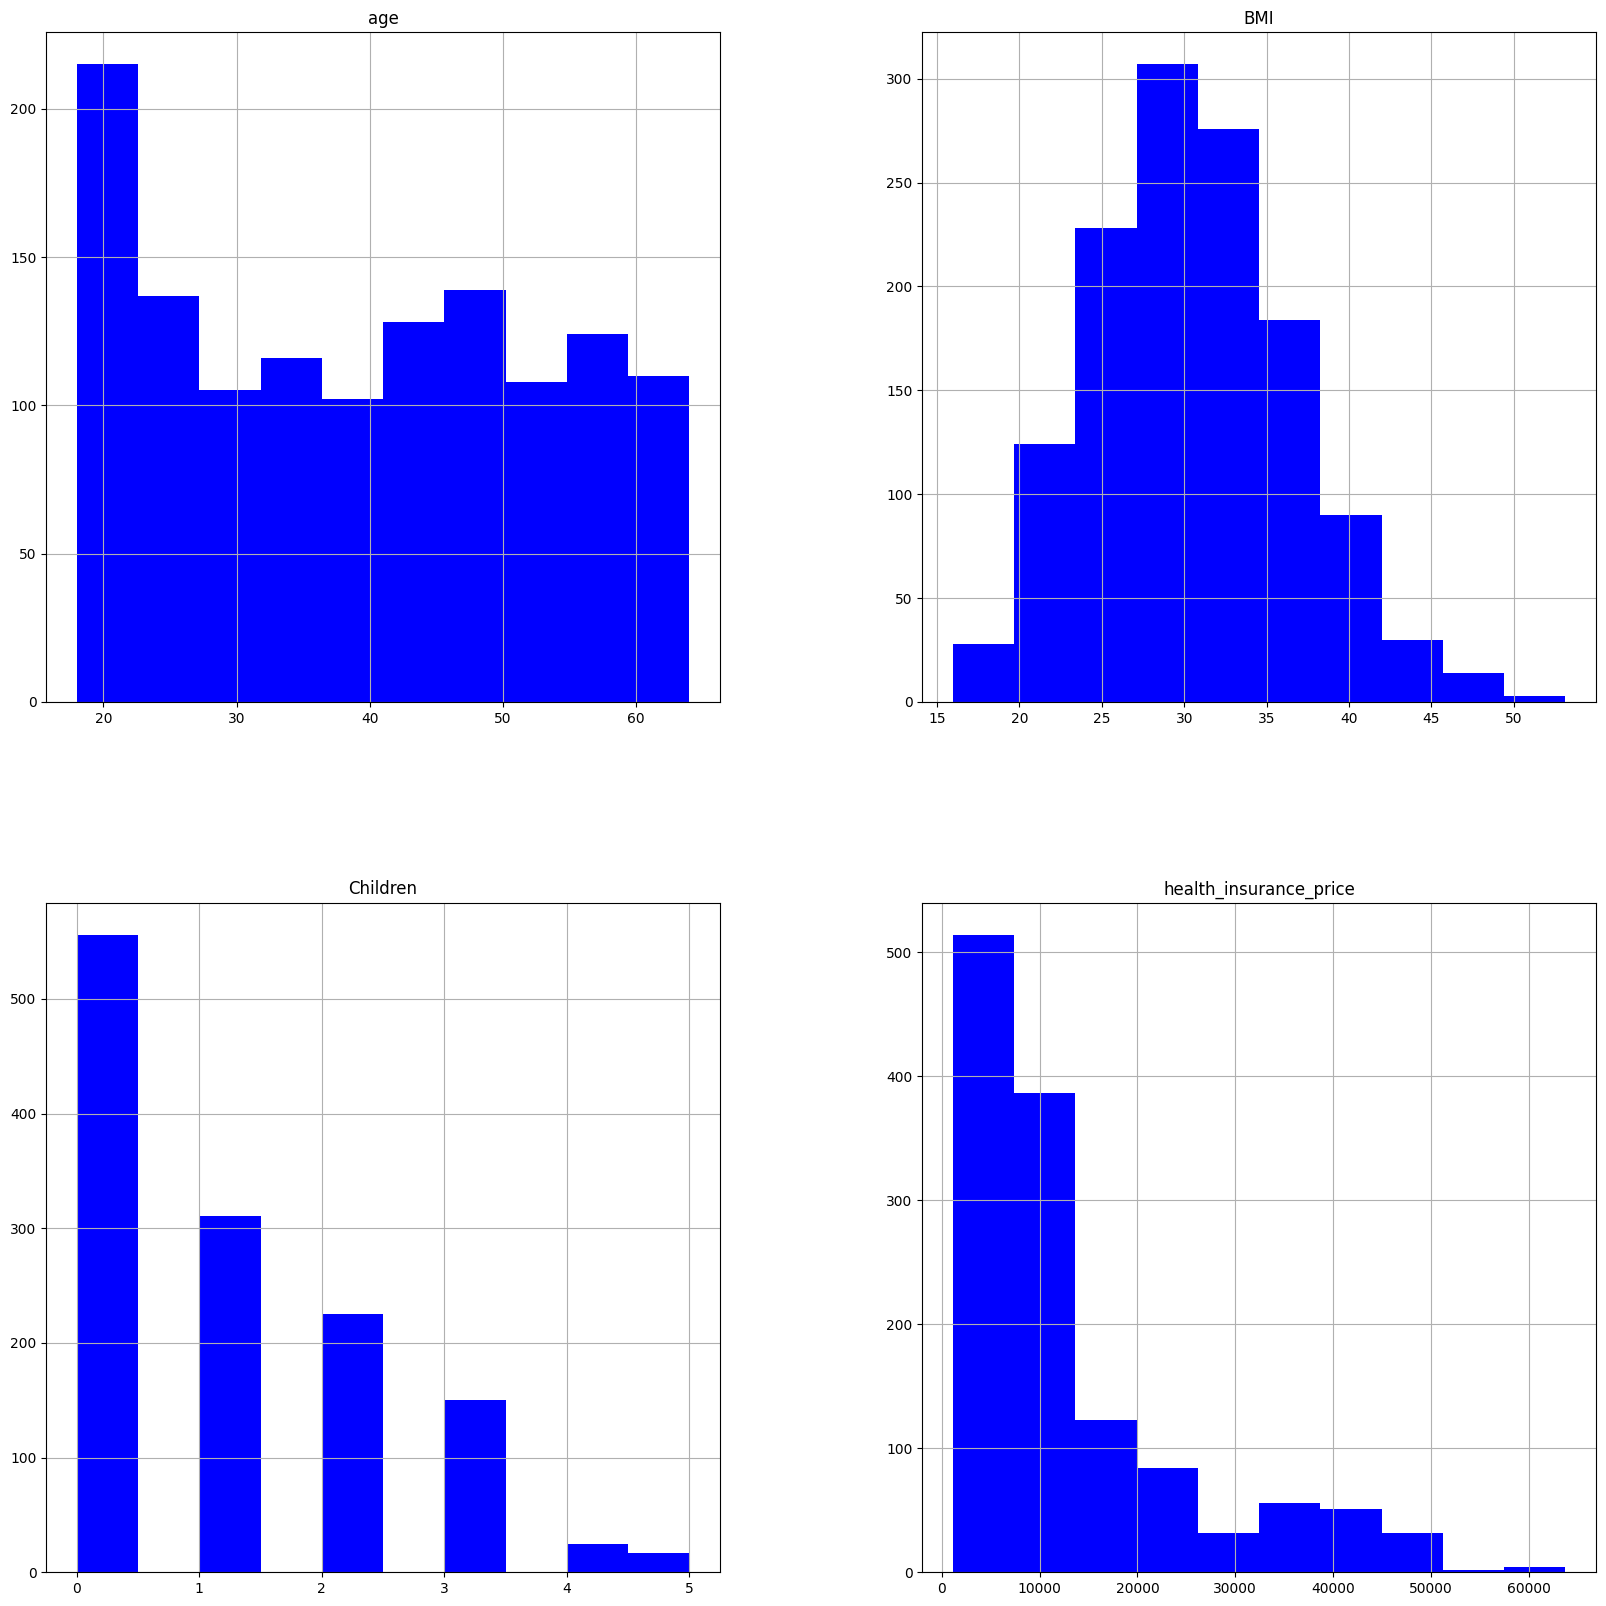

In [ ]:

# Histogram:
data1.hist(figsize=(20,20), color='blue')
plt.show()

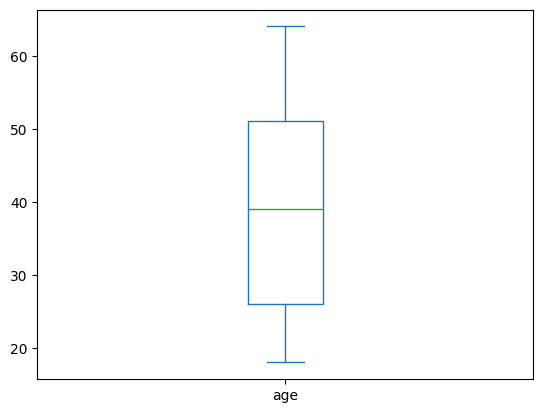

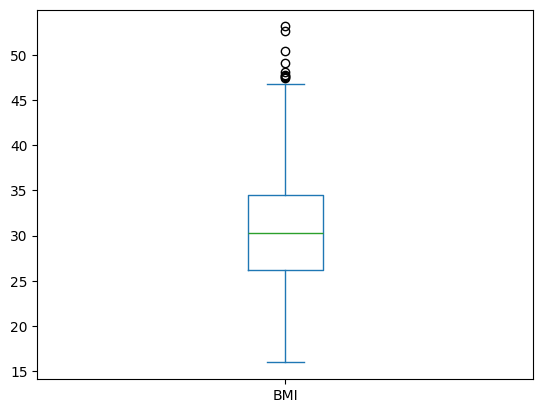

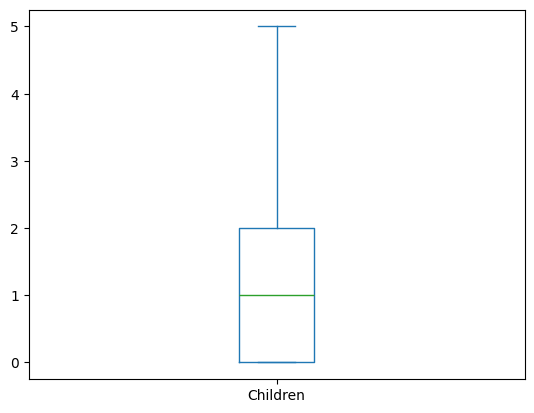

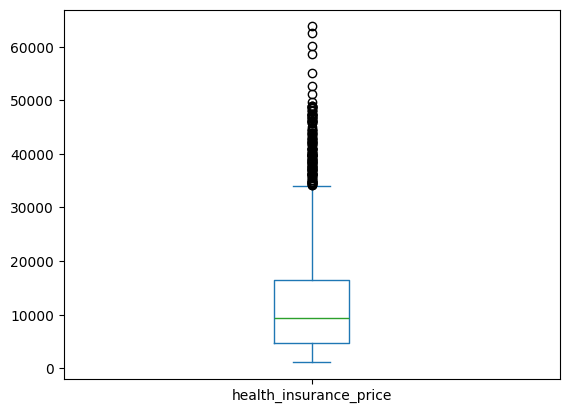

In [ ]:
# BoxPlot:
for col in Numerical_columns:
    data1[col].plot(kind='box')
    plt.show()

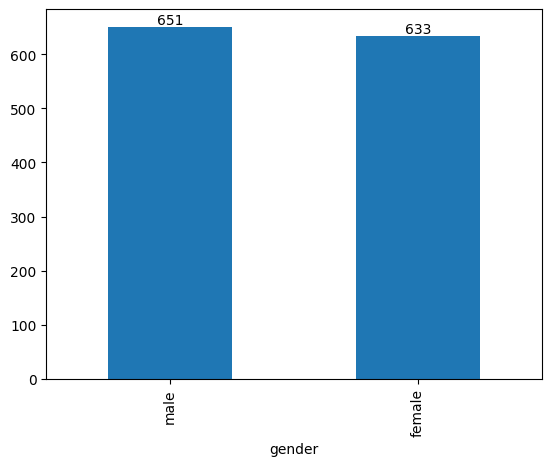

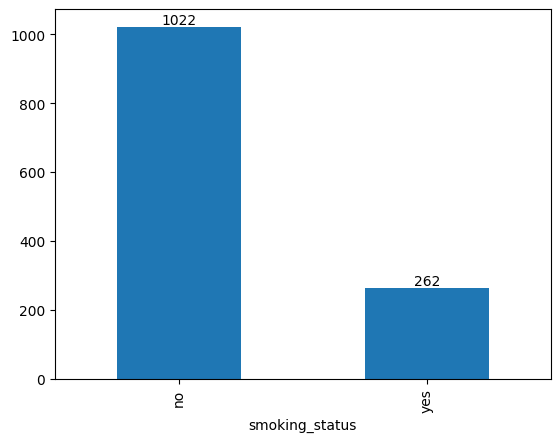

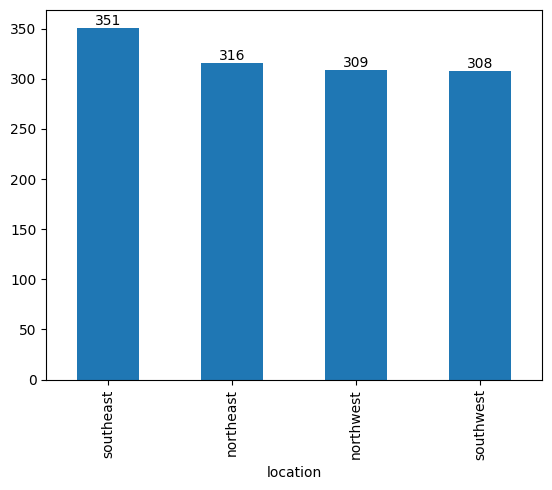

In [ ]:
# Bar Chart
for col in Categorical_columns:
    ax = data1[col].value_counts().plot(kind = 'bar')
    for i in ax.containers:
        ax.bar_label(i)
    plt.show()

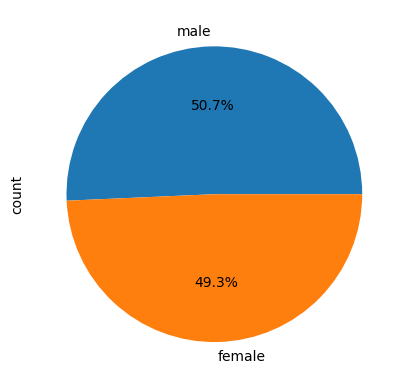

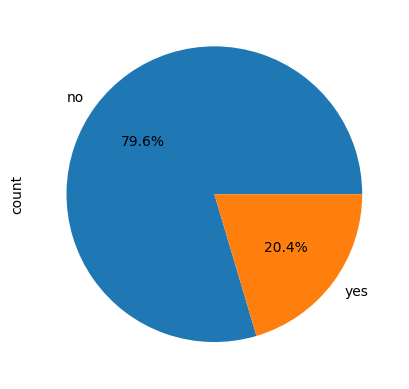

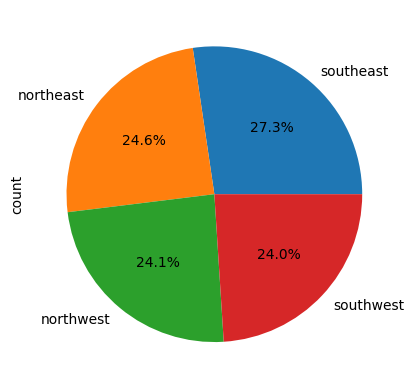

In [ ]:
# Pie Plot

for col in Categorical_columns:
  data1[col].value_counts().plot(kind = 'pie', autopct= '%1.1f%%')
  plt.show()

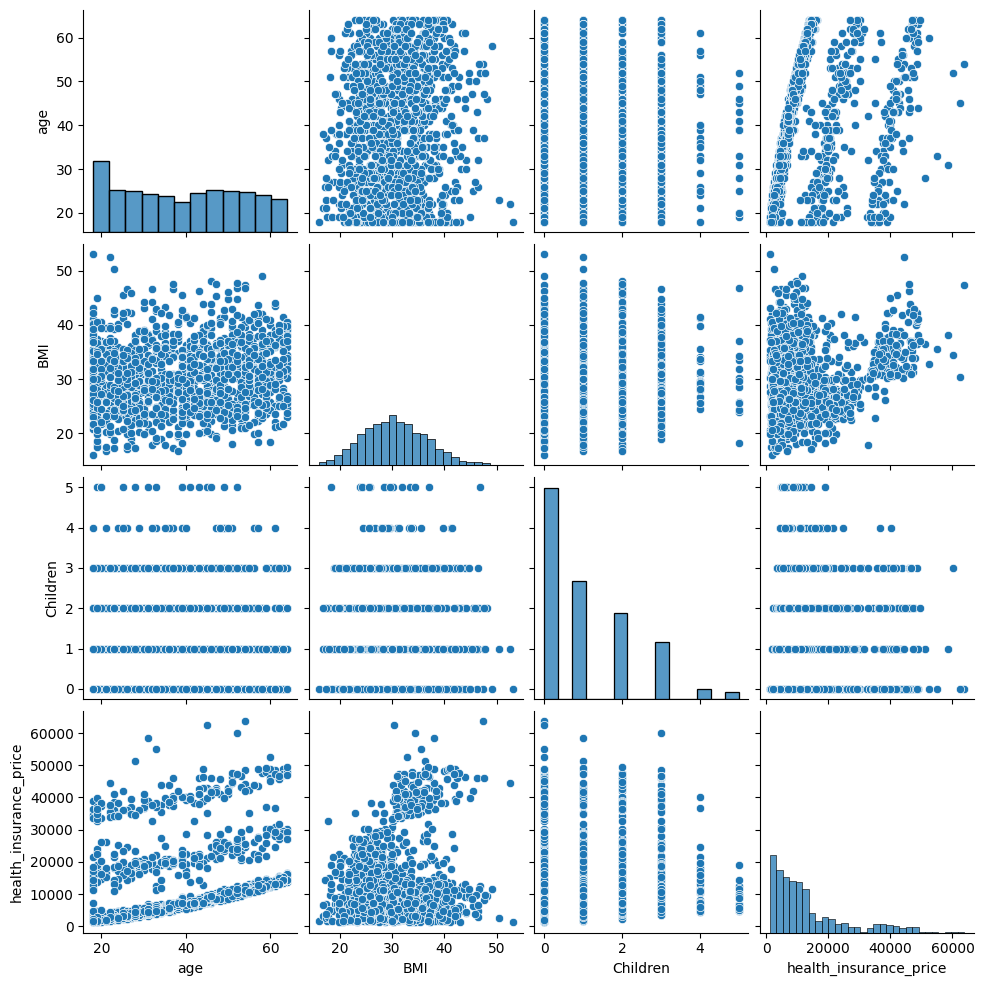

In [ ]:
#pairplot
sns.pairplot(data1)
plt.show()

In [ ]:
# Correlation Matrix
corr_data = data1[['age', 'BMI', 'health_insurance_price']].corr()
corr_data

,age,BMI,health_insurance_price
age,1.000000,0.110636,0.304755
BMI,0.110636,1.000000,0.196716
health_insurance_price,0.304755,0.196716,1.000000


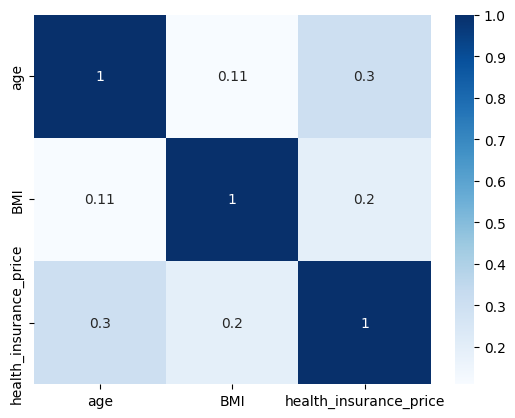

In [ ]:
sns.heatmap(corr_data, annot=True, cmap='Blues')
plt.show()

#Objective:
To build and evaluate a Linear Regression model that predicts health insurance prices based on demographic
 and lifestyle features such as age, gender, BMI, number of children, smoking status, and location.

In [ ]:
# Label encoding: where need to convert categorical data into numerical



In [ ]:

# Data Pre-Processing

In [ ]:
# Import LabelEncoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() #if we initialise label encoder in one variable like le so we don't need to type lable encoder in every encoding only use le

In [ ]:
# Label encoding categorical columns
data1['gender'] = le.fit_transform(data1['gender'])

In [ ]:
data1['smoking_status'] = le.fit_transform(data1['smoking_status'])

In [ ]:
data1['location'] = le.fit_transform(data1['location'])

In [ ]:
data1

,age,gender,BMI,Children,smoking_status,location,health_insurance_price
1,18.0,1,33.770,1,0,2,1725.55230
2,28.0,1,33.000,3,0,2,4449.46200
3,33.0,1,22.705,0,0,1,21984.47061
4,32.0,1,28.880,0,0,1,3866.85520
5,31.0,0,25.740,0,0,2,3756.62160
...,...,...,...,...,...,...,...
1333,50.0,1,30.970,3,0,1,10600.54830
1334,18.0,0,31.920,0,0,0,2205.98080
1335,18.0,0,36.850,0,0,2,1629.83350
1336,21.0,0,25.800,0,0,3,2007.94500


In [ ]:
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
# Define features (X) and target (y)
X = data1.drop("health_insurance_price", axis=1)
y = data1["health_insurance_price"]

In [ ]:
#  Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)


Training Set Size: (1027, 6)
Testing Set Size: (257, 6)


In [ ]:
#  Model Training
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully!")


Model Training Completed Successfully!


In [ ]:
# Step 6: Model Coefficients "General linear equation: Y=β0+β1X1+β2X2+β3X3+...+βnXn+ε "
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print("\nModel Coefficients:")
print(coeff_df)
print("Intercept:", model.intercept_)


Model Coefficients:
                 Coefficient
age               258.233190
gender             79.378199
BMI               303.627746
Children          429.046341
smoking_status  23776.373395
location         -360.080370
Intercept: -11105.206278310523


The linear Regression model predicts health_insurance_price by using equation
Y = β0+β1X1+β2X2+β3X3+...+βnXn+ε

where Y = health_insurance_price
β0 = intercept(this is a strating price befor adding age, gender, children etc.)
β1,β2... = coefficients(age coefficient, gender coefficient...)
x1,x2,..are independents (age ,genders columns)

Age = 258.23
For each additional year of age, insurance price increases by  258.23

gender = 79.37
it's based on gender male and female. if male = 1 ,female = 0
then males pay 79 more on average.

BMI = 303.63
For each 1-unit increase in BMI, insurance price goes up by 303.63. Higher BMI is strongly associated with higher premiums.

Children: 429.05
Each additional child increases the predicted insurance price by 429.05.

smoking_status =  23776.37
If smoking_status=1 means smoker, then being a smoker increases insurance price by 23,776

location: 300.08
The encoded location value impacts price by 300 per unit change.

In [ ]:
# Step : 7 Predictions
y_pred = model.predict(X_test)

In [ ]:
# Step 8: Model Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.3f}")


Model Performance:
Mean Absolute Error (MAE): 4409.50
Mean Squared Error (MSE): 44056509.99
R² Score: 0.727


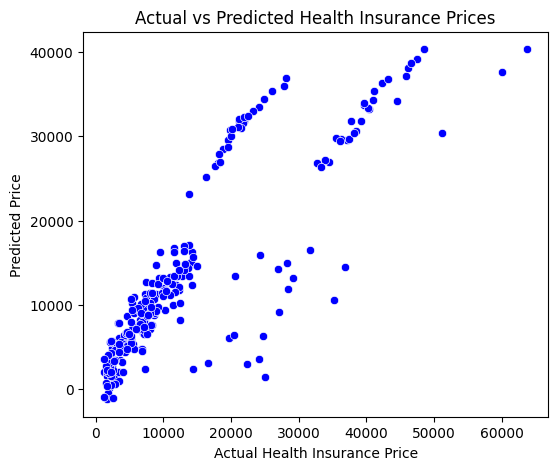

In [ ]:
# Step 9: Visualization

# Actual vs Predicted Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, color="blue")
plt.xlabel("Actual Health Insurance Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Health Insurance Prices")
# Save the graph
plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

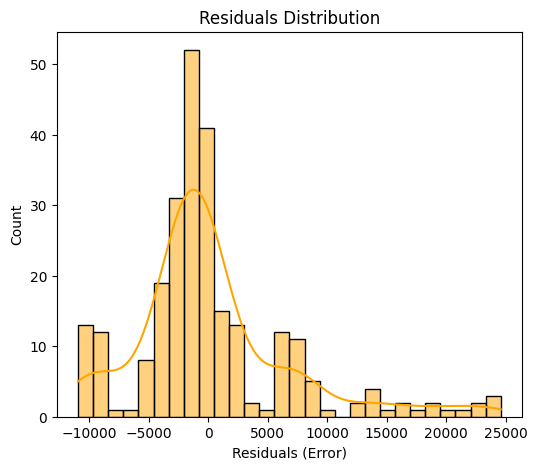

In [ ]:
# Residual Plot
plt.figure(figsize=(6, 5))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='orange')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (Error)")

# Save the plot
plt.savefig("residuals_distribution.png", dpi=300, bbox_inches='tight')

plt.show()